In [1]:
# Animating chirp scans
# Documentation of matplotlib.animation: https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html

from matplotlib import patches as ptc
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.colors as colors
import pickle
import numpy as np
from IPython.display import HTML, Image


In [2]:
def central_cut(real_data, source_pos, edge_relax):
    """
    Get the central hexagonal part of the real space data.
    real_data: [[x_coord, y_coord, amp, phase], ...].
    Also shift the origin to the source position
    """
    
    x = real_data[:, 0] - source_pos[0]
    y = real_data[:, 1] - source_pos[1]
    amp = real_data[:, 2]
    phase = real_data[:, 3]

    x_unit = 10*np.sqrt(3)/4*1e-3
    y_unit = 7.5*1e-3

    # Get the central hexagon
    y_mask = (np.abs(y) <= y_unit*8.2) 
    xy_mask_1 = (np.abs(y+y_unit/x_unit*x) <= y_unit*16+edge_relax)
    xy_mask_2 = (np.abs(y-y_unit/x_unit*x) <= y_unit*16+edge_relax)
    source_mask = (np.sqrt(x**2 + y**2) > edge_relax)  # Avoid the source point
    mask = y_mask & xy_mask_1 & xy_mask_2 & source_mask


    return np.column_stack((x[mask], y[mask], amp[mask], phase[mask]))

In [14]:
# making the animation with matplotlib.animation



folder = "../../../data/kagome-02.26.2022-center-sim/" # Data folder

# Figure settings
freq = 14.4
x_unit = 10*np.sqrt(3)/4*1e-3
y_unit = 7.5*1e-3
radius = 3.5*1e-3

# Load data from preprocessd file. Can only plot real space data at one frequency
# Real data format: [x_coord, y_coord, amplitude, phase]
with open(folder + "preprocessed/_{:.0f}.0_0.pkl".format(freq*1000),'rb') as f: 
    real_data = pickle.load(f)    
    
real_data = central_cut(real_data, source_pos=(2*x_unit, 0), edge_relax=radius*0.2)

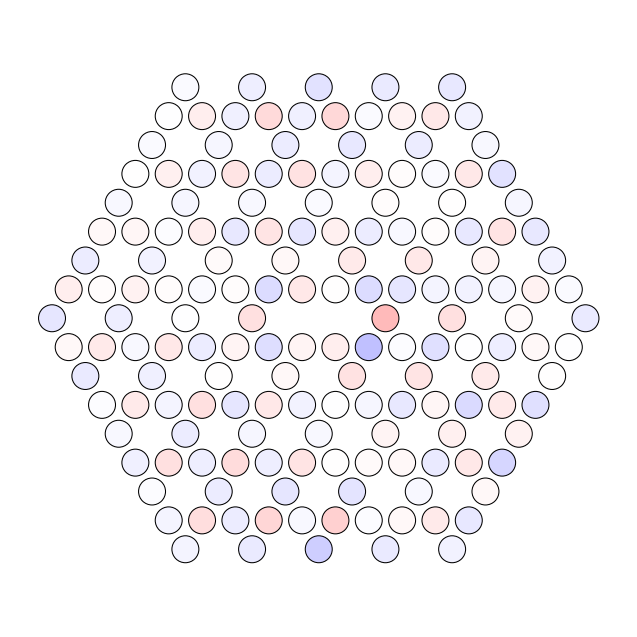

In [15]:


fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
max_amp_flat = np.max(real_data, axis=0)[2]
plt.yticks([])
plt.xticks([])

cavities = []
t = 0 # initial time
dt = 0.1 # time step
radius = 3.5 # Cavity radius: [mm]

ampdata = real_data[:,2]
max_amp_flat = np.max(ampdata)
phasedata = real_data[:,3]
x_list = real_data[:,0]
y_list = real_data[:,1]

# Find the (1,1) point to lock the phase reference
ref_pt_index = np.argmin(np.sqrt((real_data[:,0]-x_unit)**2 + (real_data[:,1]-y_unit)**2))
phase_ref = phasedata[ref_pt_index]
phasedata -= phase_ref


frame_num = 60 # total frame number

for i in range(len(real_data)): 
    x_center = x_list[i]*1e3
    y_center = y_list[i]*1e3

    # If you want to rescale the amplitude color map, uncomment the line below
    # ampdata.append(np.sqrt(point[2])*np.sqrt(max_amp))
    pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))

    # plot the 
    circle = ptc.Ellipse((x_center, y_center), 
                     width = radius*2, 
                     height = radius*2, 
                     edgecolor='black', 
                     facecolor = plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)),
                     fill = True, 
                     alpha = 1,
                     linewidth = 0.25)
    cavities.append(circle)
    ax.add_patch(cavities[-1])
        
def init():
    """initialize animation"""
    global cavities
      
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))  
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities
    
def animate(j):
    """perform animation step"""
    global t, dt, cavities, ampdata, phasedata
    t += dt
                            
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]+j*360/frame_num))
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities

# creating the animation
ani = animation.FuncAnimation(fig, animate, frames = frame_num, interval = 2, blit = True, init_func = init)

In [16]:
# saving the animation in a gif file
filename = '{:.2f}kHz-sim.gif'.format(freq)
folder = '../../../output/paper_new/animations/'
ani.save(folder + filename, writer = 'imagemagick', fps = 120)

MovieWriter imagemagick unavailable; using Pillow instead.


In [6]:
# displaying the animation (works in jupyter notebook but might not work in vs code)

Image(url = folder + 'animations/' + filename)

In [17]:
# making the animation with matplotlib.animation



folder = "../../../data/kagome-02.26.2022-center-sim/" # Data folder

# Figure settings
freq = 4
x_unit = 10*np.sqrt(3)/4*1e-3
y_unit = 7.5*1e-3
radius = 3.5*1e-3

# Load data from preprocessd file. Can only plot real space data at one frequency
# Real data format: [x_coord, y_coord, amplitude, phase]
with open(folder + "preprocessed/_{:.0f}.0_0.pkl".format(freq*1000),'rb') as f: 
    real_data = pickle.load(f)    
    
real_data = central_cut(real_data, source_pos=(2*x_unit, 0), edge_relax=radius*0.2)

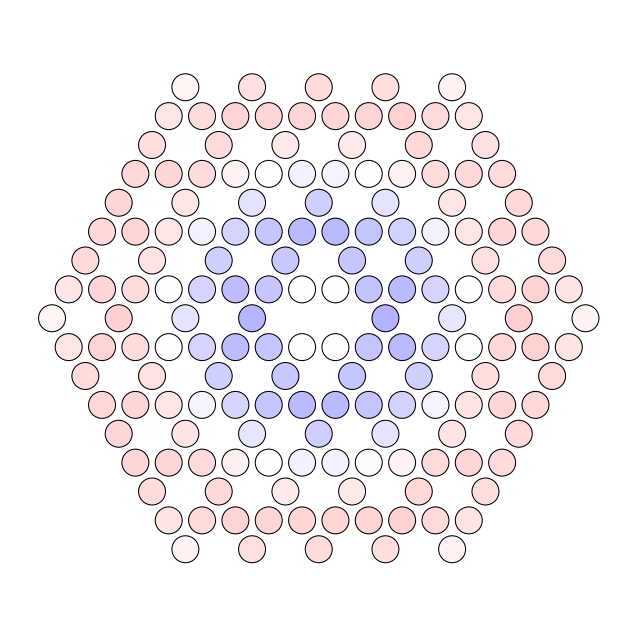

In [19]:
fig = plt.figure(figsize=(2.5,2.5), dpi=300)
ax = fig.gca()
ax.set_aspect("equal")
ax.set_xlim(-75, 75)
ax.set_ylim(-75, 75)
ax.axis('off')
plt.yticks([])
plt.xticks([])

cavities = []
ampdata = []
phasedata = []
t = 0 # initial time
dt = 0.1 # time step
radius = 3.5 # Cavity radius: [mm]

ampdata = real_data[:,2]
phasedata = real_data[:,3]
x_list = real_data[:,0]
y_list = real_data[:,1]

# Find the (1,1) point to lock the phase reference
ref_pt_index = np.argmin(np.sqrt((real_data[:,0]-x_unit)**2 + (real_data[:,1]-y_unit)**2))
phase_ref = phasedata[ref_pt_index]
phasedata -= phase_ref


frame_num = 60 # total frame number

for i in range(len(real_data)): 
    x_center = x_list[i]*1e3
    y_center = y_list[i]*1e3

    # If you want to rescale the amplitude color map, uncomment the line below
    # ampdata.append(np.sqrt(point[2])*np.sqrt(max_amp))
    pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))

    # plot the 
    circle = ptc.Ellipse((x_center, y_center), 
                     width = radius*2, 
                     height = radius*2, 
                     edgecolor='black', 
                     facecolor = plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)),
                     fill = True, 
                     alpha = 1,
                     linewidth = 0.25)
    cavities.append(circle)
    ax.add_patch(cavities[-1])
    
def init():
    """initialize animation"""
    global cavities
      
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]))  
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities
    
def animate(j):
    """perform animation step"""
    global t, dt, cavities, ampdata, phasedata
    t += dt
                            
    for i in range(len(cavities)):
        pressure = ampdata[i]*np.sin(np.deg2rad(phasedata[i]+j*360/frame_num))
        cavities[i].set_facecolor(plt.cm.bwr((pressure+max_amp_flat)/(2.0*max_amp_flat)))
                             
    return cavities

# creating the animation
ani = animation.FuncAnimation(fig, animate, frames = frame_num, interval = 2, blit = True, init_func = init)

In [20]:
# saving the animation in a gif file
filename = '{:.2f}kHz-sim.gif'.format(freq)
folder = '../../../output/paper_new/animations/'
ani.save(folder + filename, writer = 'imagemagick', fps = 120)

MovieWriter imagemagick unavailable; using Pillow instead.
